In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv(r'data\Laptop Prices Dataset\laptopPrice.csv')
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


# 1. Inspect the Data

In [46]:
df.duplicated().sum()

21

In [47]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [48]:
df.shape

(802, 19)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 802 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand              802 non-null    object
 1   processor_brand    802 non-null    object
 2   processor_name     802 non-null    object
 3   processor_gnrtn    802 non-null    object
 4   ram_gb             802 non-null    object
 5   ram_type           802 non-null    object
 6   ssd                802 non-null    object
 7   hdd                802 non-null    object
 8   os                 802 non-null    object
 9   os_bit             802 non-null    object
 10  graphic_card_gb    802 non-null    object
 11  weight             802 non-null    object
 12  warranty           802 non-null    object
 13  Touchscreen        802 non-null    object
 14  msoffice           802 non-null    object
 15  Price              802 non-null    int64 
 16  rating             802 non-null    object
 17  Nu

In [50]:
df.dtypes

brand                object
processor_brand      object
processor_name       object
processor_gnrtn      object
ram_gb               object
ram_type             object
ssd                  object
hdd                  object
os                   object
os_bit               object
graphic_card_gb      object
weight               object
warranty             object
Touchscreen          object
msoffice             object
Price                 int64
rating               object
Number of Ratings     int64
Number of Reviews     int64
dtype: object

In [51]:
# memory_usage : a method that shows the memory usage of each column in the DataFrame
df.memory_usage()

Index                6416
brand                6416
processor_brand      6416
processor_name       6416
processor_gnrtn      6416
ram_gb               6416
ram_type             6416
ssd                  6416
hdd                  6416
os                   6416
os_bit               6416
graphic_card_gb      6416
weight               6416
warranty             6416
Touchscreen          6416
msoffice             6416
Price                6416
rating               6416
Number of Ratings    6416
Number of Reviews    6416
dtype: int64

In [52]:
df.describe(include='all')

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
count,802,802,802,802,802,802,802,802,802,802,802,802,802,802,802,802.000000,802,802.00000,802.000000
unique,8,3,11,8,4,6,7,4,3,2,5,3,4,2,2,NaN,5,NaN,NaN
top,ASUS,Intel,Core i5,11th,8 GB,DDR4,512 GB,0 GB,Windows,64-bit,0 GB,Casual,1 year,No,No,NaN,4 stars,NaN,NaN
freq,243,594,284,328,404,690,389,602,763,693,557,509,498,706,522,NaN,437,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76625.543641,NaN,299.84414,36.089776
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45232.984422,NaN,1001.78442,118.313553
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16990.000000,NaN,0.00000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45990.000000,NaN,0.00000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63990.000000,NaN,17.00000,2.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89525.000000,NaN,140.25000,18.000000


C:\Users\PC-MOH\AppData\Local\Temp\ipykernel_18128\3481956292.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax=ax)


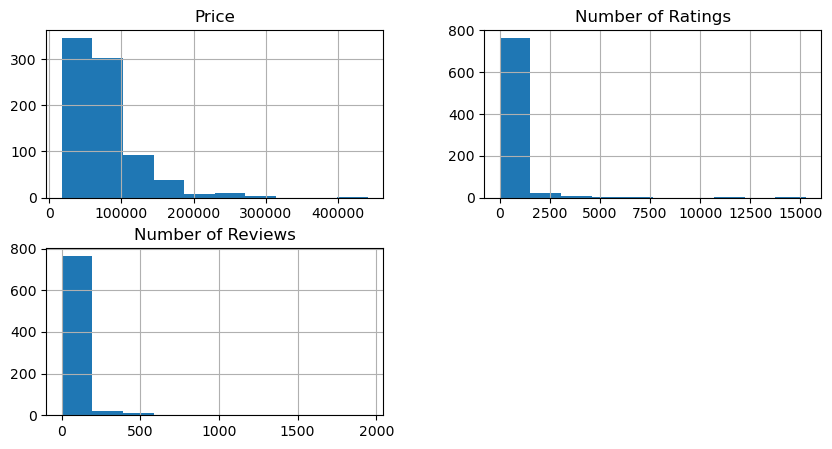

In [53]:
# Data Distribution
fig, ax = plt.subplots(figsize=(10,5))
df.hist(ax=ax)
plt.show()

# 2. Data Cleaning (Data Wrangling)

In [54]:
df['weight'].value_counts()

weight
Casual        509
ThinNlight    254
Gaming         39
Name: count, dtype: int64

In [55]:
# Rename misleading columns
df.rename(columns={'weight': 'usage_type'}, inplace=True)
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,usage_type,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [56]:
# Clean numeric columns (like "4 GB", "0 GB". Removing units and convert to numbers)
cols = ['ram_gb', 'ssd', 'hdd', 'graphic_card_gb']
for col in cols:
  df[col] = df[col].apply(lambda x: int(x.replace('GB', '')))

# Removing star/stars
df['rating'] = df['rating'].apply(lambda x: int(x.replace('stars', '').replace('star', '')))

# Clean CPU Generation column (Removing units)
def rename_cpu(cpu):
  if 'th' in cpu:
    return int(cpu.replace('th', ''))
  else:
    return 0
df['processor_gnrtn'] = df['processor_gnrtn'].apply(rename_cpu)

df.tail()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,usage_type,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
818,ASUS,AMD,Ryzen 9,0,4,DDR4,1024,0,Windows,64-bit,0,Casual,1 year,No,No,135990,3,0,0
819,ASUS,AMD,Ryzen 9,0,4,DDR4,1024,0,Windows,64-bit,0,Casual,1 year,No,No,144990,3,0,0
820,ASUS,AMD,Ryzen 9,0,4,DDR4,1024,0,Windows,64-bit,4,Casual,1 year,No,No,149990,3,0,0
821,ASUS,AMD,Ryzen 9,0,4,DDR4,1024,0,Windows,64-bit,4,Casual,1 year,No,No,142990,3,0,0
822,Lenovo,AMD,Ryzen 5,10,8,DDR4,512,0,DOS,64-bit,0,ThinNlight,No warranty,No,No,57490,4,18,4


In [57]:
# Convert ratings to numeric
df['Number of Ratings'] = df['Number of Ratings'].astype(int)
df['Number of Reviews'] = df['Number of Reviews'].astype(int)

In [58]:
# Handle missing data
df.isnull().sum()

brand                0
processor_brand      0
processor_name       0
processor_gnrtn      0
ram_gb               0
ram_type             0
ssd                  0
hdd                  0
os                   0
os_bit               0
graphic_card_gb      0
usage_type           0
warranty             0
Touchscreen          0
msoffice             0
Price                0
rating               0
Number of Ratings    0
Number of Reviews    0
dtype: int64

# 3. Exploratory Data Analysis (EDA)

c:\Users\PC-MOH\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


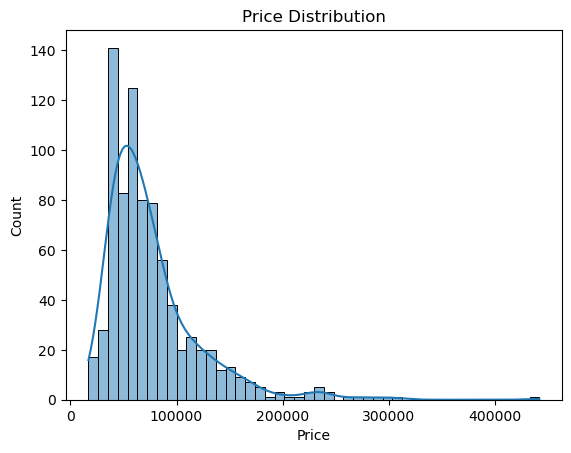

In [59]:
# a) Univariate Analysis (Single Variable)
sns.histplot(df['Price'], kde=True)
plt.title('Price Distribution')
plt.show()

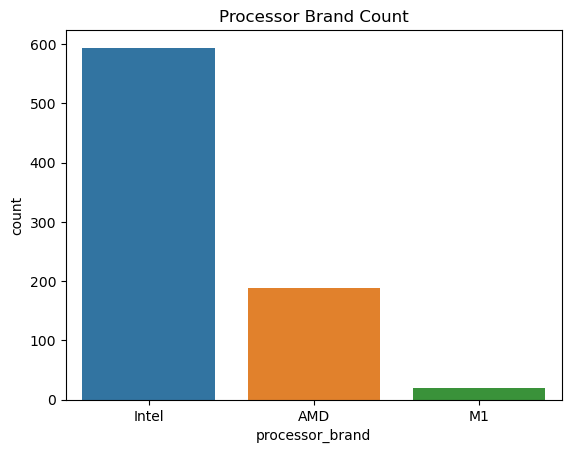

In [60]:
sns.countplot(x='processor_brand', data=df)
plt.title('Processor Brand Count')
plt.show()

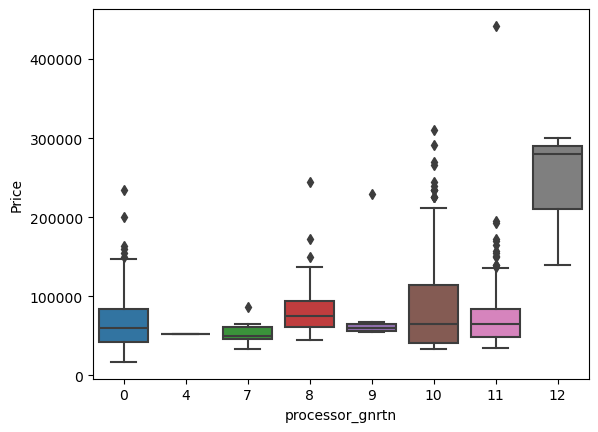

In [61]:
# b) Bivariate Analysis (Relationships)
sns.boxplot(x='processor_gnrtn', y='Price', data=df)
plt.show()

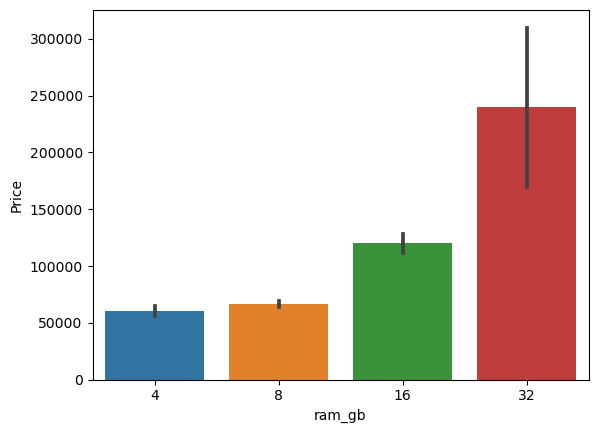

In [62]:
sns.barplot(x='ram_gb', y='Price', data=df)
plt.show()

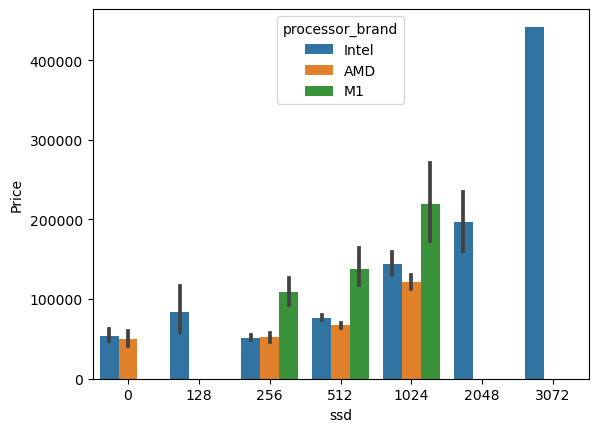

In [63]:
sns.barplot(x='ssd', y='Price', data=df, hue='processor_brand')
plt.show()

<Axes: >

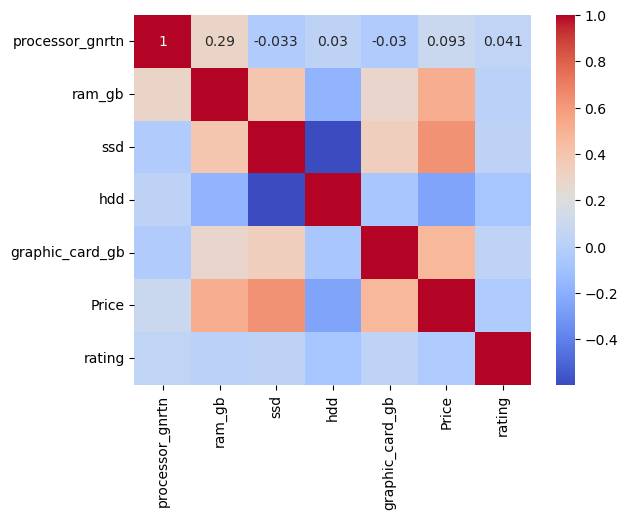

In [64]:
# c) Correlation Analysis
numeric_df = df.select_dtypes(['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

In [65]:
df.corr(numeric_only=True)

,processor_gnrtn,ram_gb,ssd,hdd,graphic_card_gb,Price,rating,Number of Ratings,Number of Reviews
processor_gnrtn,1.000000,0.290861,-0.033478,0.030126,-0.029589,0.093286,0.041423,-0.075336,-0.090634
ram_gb,0.290861,1.000000,0.390191,-0.173592,0.279552,0.516454,0.016501,-0.112645,-0.114330
ssd,-0.033478,0.390191,1.000000,-0.595347,0.334720,0.628734,0.033969,-0.172900,-0.175805
hdd,0.030126,-0.173592,-0.595347,1.000000,-0.063621,-0.251266,-0.072537,0.120181,0.127730
graphic_card_gb,-0.029589,0.279552,0.334720,-0.063621,1.000000,0.467499,0.037722,-0.018904,-0.014043
Price,0.093286,0.516454,0.628734,-0.251266,0.467499,1.000000,-0.040564,-0.152553,-0.156791
rating,0.041423,0.016501,0.033969,-0.072537,0.037722,-0.040564,1.000000,0.144927,0.140957
Number of Ratings,-0.075336,-0.112645,-0.172900,0.120181,-0.018904,-0.152553,0.144927,1.000000,0.991062
Number of Reviews,-0.090634,-0.114330,-0.175805,0.127730,-0.014043,-0.156791,0.140957,0.991062,1.000000


# 4. Feature Engineering

In [66]:
df['storage_total'] = df['ssd'] + df['hdd']
df['Price_DZD'] = df['Price'] * 2.8194    # 1 Indian Rupee = 2.8194 DZD (2025)
df['is_touchscreen'] = (df['Touchscreen'] == 'Yes').astype('int')

df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,...,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews,storage_total,Price_DZD,is_touchscreen
0,ASUS,Intel,Core i3,10,4,DDR4,0,1024,Windows,64-bit,...,No warranty,No,No,34649,2,3,0,1024,97689.3906,0
1,Lenovo,Intel,Core i3,10,4,DDR4,0,1024,Windows,64-bit,...,No warranty,No,No,38999,3,65,5,1024,109953.7806,0
2,Lenovo,Intel,Core i3,10,4,DDR4,0,1024,Windows,64-bit,...,No warranty,No,No,39999,3,8,1,1024,112773.1806,0
3,ASUS,Intel,Core i5,10,8,DDR4,512,0,Windows,32-bit,...,No warranty,No,No,69990,3,0,0,512,197329.8060,0
4,ASUS,Intel,Celeron Dual,0,4,DDR4,0,512,Windows,64-bit,...,No warranty,No,No,26990,3,0,0,512,76095.6060,0


# 5. Insights & Reporting

In [67]:
# Which brand offers the best price-to-rating ratio?
df['price_to_rating'] = df['Price_DZD'] / df['rating']
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,...,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews,storage_total,Price_DZD,is_touchscreen,price_to_rating
0,ASUS,Intel,Core i3,10,4,DDR4,0,1024,Windows,64-bit,...,No,No,34649,2,3,0,1024,97689.3906,0,48844.6953
1,Lenovo,Intel,Core i3,10,4,DDR4,0,1024,Windows,64-bit,...,No,No,38999,3,65,5,1024,109953.7806,0,36651.2602
2,Lenovo,Intel,Core i3,10,4,DDR4,0,1024,Windows,64-bit,...,No,No,39999,3,8,1,1024,112773.1806,0,37591.0602
3,ASUS,Intel,Core i5,10,8,DDR4,512,0,Windows,32-bit,...,No,No,69990,3,0,0,512,197329.8060,0,65776.6020
4,ASUS,Intel,Celeron Dual,0,4,DDR4,0,512,Windows,64-bit,...,No,No,26990,3,0,0,512,76095.6060,0,25365.2020


In [68]:
df.loc[df['price_to_rating'].idxmin()]

brand                      Lenovo
processor_brand             Intel
processor_name       Celeron Dual
processor_gnrtn                 0
ram_gb                          4
ram_type                   LPDDR4
ssd                             0
hdd                           512
os                        Windows
os_bit                     32-bit
graphic_card_gb                 0
usage_type                 Casual
warranty              No warranty
Touchscreen                    No
msoffice                       No
Price                       16990
rating                          3
Number of Ratings             414
Number of Reviews              54
storage_total                 512
Price_DZD               47901.606
is_touchscreen                  0
price_to_rating         15967.202
Name: 194, dtype: object

In [69]:
# Does SSD presence significantly impact price?
df[['ssd', 'Price_DZD']].corr()   # 60%

,ssd,Price_DZD
ssd,1.000000,0.628734
Price_DZD,0.628734,1.000000


In [70]:
# How does RAM affect rating or price?
df[['ram_gb', 'Price_DZD']].corr()  # 51%

,ram_gb,Price_DZD
ram_gb,1.000000,0.516454
Price_DZD,0.516454,1.000000


In [99]:
# 📊 Average Price by Brand: Which brands are premium vs. budget-friendly?
brands_df = df.groupby(by='brand', as_index=False)['Price'].mean().sort_values('Price')
brands_df

,brand,Price
2,Avita,56346.500000
3,DELL,60788.953020
7,acer,72420.039216
5,Lenovo,72920.208333
4,HP,73640.272059
1,ASUS,79426.020576
6,MSI,98713.020000
0,APPLE,157081.304348


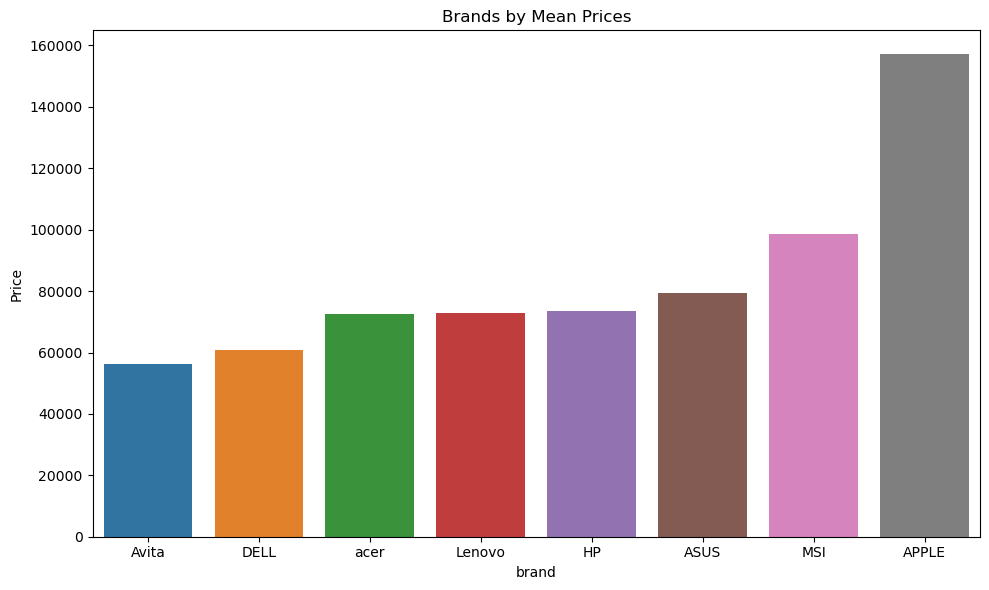

In [100]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=brands_df, x='brand', y='Price', ax=ax)
plt.title('Brands by Mean Prices')
plt.tight_layout()
plt.show()

In [73]:
# 📉 Price vs. CPU Generation: Does newer generation significantly increase price?
cpu_gen_df = df.groupby(by='processor_gnrtn', as_index=False)['Price'].mean().sort_values(by='Price', ascending=False)
cpu_gen_df

,processor_gnrtn,Price
7,12,239990.000000
5,10,88926.621212
4,9,87891.666667
3,8,86535.171429
6,11,72065.625000
0,0,69181.669643
2,7,54779.285714
1,4,52490.000000


c:\Users\PC-MOH\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\PC-MOH\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


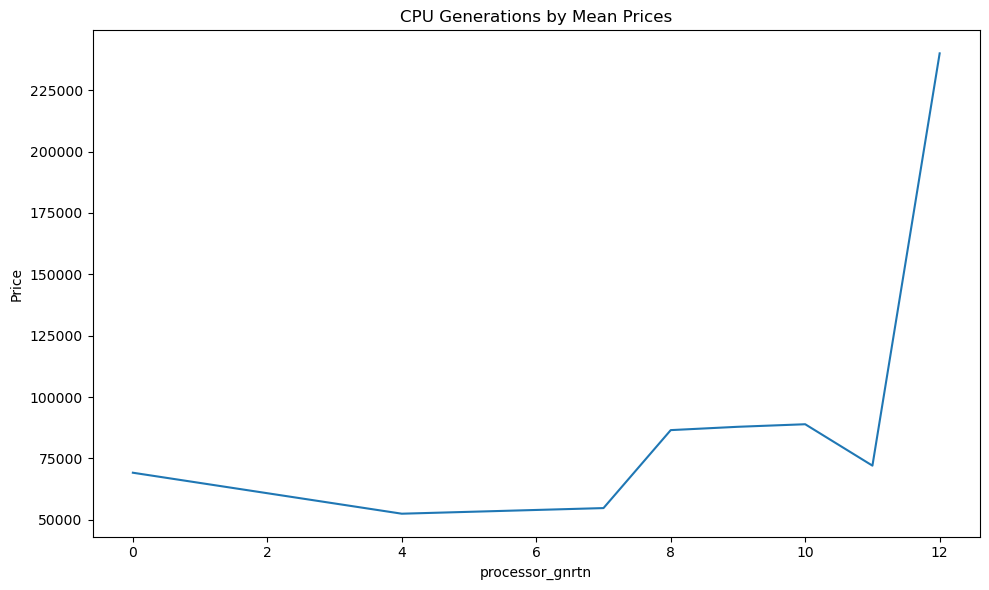

In [74]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=cpu_gen_df, x='processor_gnrtn', y='Price', markers='o', ax=ax)
plt.title('CPU Generations by Mean Prices')
plt.tight_layout()
plt.show()

In [98]:
# Laptops with 512GB SSD are on average 70% more expensive than those with HDD only
df[(df['hdd'] > 0) & (df['ssd'] <= 0)]['Price'].mean()  /  df[(df['ssd'] == 512)]['Price'].mean()

0.7047825171050899